# Analyse Exploratoire des Données (EDA) — Corpus Darija MT

**Projet R&D** : Traduction Automatique Darija (MT) — Shard 2  
**Étudiants** : Yassine Boumhand · Abdourazak Akillou Illa  
**Encadrant** : Pr. Imad HAFIDI — Module Text Mining — 2025/2026

---

## Objectif du notebook

Ce notebook présente l'analyse exploratoire complète du corpus parallèle Darija–Anglais–MSA en **trois phases** :

| Phase | Datasets | Statut | Objectif |
|-------|---------|--------|----------|
| **Phase 1** | Silver brut + Gold brut (concaténés) | Avant annotation | Identifier les anomalies, évaluer la qualité initiale du Silver & Gold Standard |
| **Phase 2** | Gold final (séparé) + Silver final (séparé) | Après annotation | Valider la qualité de chaque corpus indépendamment |
| **Phase 3** | Spot-check Silver (1%/classe) | Validation humaine | Prouver statistiquement la qualité via BLEU / chrF++ |

### Pourquoi séparer Gold et Silver en Phase 2 ?

Après annotation, les deux datasets ont des **natures fondamentalement différentes** :
- Le **Gold** est annoté 100% manuellement → vérité terrain absolue → utilisé comme **Test Set**
- Le **Silver** est généré par GPT-4o-mini + spot-check → données d'entraînement → utilisé comme **Training Set**

Les analyser séparément permet de montrer la cohérence entre les deux et de mettre en valeur la distinction méthodologique entre vérité terrain et données d'entraînement.

---

In [104]:
# ── Décommenter à la première exécution ───────────────────────────────
# !pip install matplotlib seaborn sacrebleu --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import sacrebleu

# ── Style global des figures ──────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize'   : (13, 5),
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ── Palettes de couleurs cohérentes sur tout le notebook ─────────────
COLORS_CLASS  = ['#3B82F6', '#10B981', '#8B5CF6', '#F59E0B']  # A B C D
COLORS_LANG   = ['#3B82F6', '#10B981', '#8B5CF6']             # Darija English MSA
COLORS_STATUS = ['#EF4444', '#F59E0B', '#10B981']             # GENERATED PARTIAL VALIDATED

# ── Patterns regex pour la détection de script ───────────────────────
ARABIC_PAT = re.compile(r'[\u0600-\u06FF]')
LATIN_PAT  = re.compile(r'[a-zA-Z]')

def has_arabic(text): return bool(ARABIC_PAT.search(str(text)))
def has_latin(text):  return bool(LATIN_PAT.search(str(text)))

def dqa_report(df, label):
    """Affiche un rapport DQA standardisé pour n'importe quel dataframe."""
    n = len(df)
    arabic_in_arabizi  = df['darija_arabizi'].fillna('').apply(has_arabic).sum()
    latin_in_darija    = (~df['darija_arabic'].fillna('').apply(has_arabic) & (df['darija_arabic'].fillna('').str.len() > 0)).sum()
    arabic_in_english  = df['english'].fillna('').apply(has_arabic).sum()
    empty_en           = (df['english'].fillna('').str.len() == 0).sum()
    empty_msa          = (df['modern_standard_arabic'].fillna('').str.len() == 0).sum()
    total              = arabic_in_arabizi + latin_in_darija + arabic_in_english + empty_en + empty_msa
    print(f'DQA — {label} ({n:,} lignes)')
    print(f'  [ISSUE 1] Arabe dans Arabizi      : {arabic_in_arabizi:>4} ({arabic_in_arabizi/n*100:.2f}%)')
    print(f'  [ISSUE 2] Latin dans Darija Arabic : {latin_in_darija:>4} ({latin_in_darija/n*100:.2f}%)')
    print(f'  [ISSUE 3] Arabe dans English       : {arabic_in_english:>4} ({arabic_in_english/n*100:.2f}%)')
    print(f'  [ISSUE 4] English vide             : {empty_en:>4} ({empty_en/n*100:.2f}%)')
    print(f'  [ISSUE 5] MSA vide                 : {empty_msa:>4} ({empty_msa/n*100:.2f}%)')
    print(f'  TOTAL anomalies                    : {total:>4} ({total/n*100:.2f}%)')
    return {
        'Arabe\ndans Arabizi': arabic_in_arabizi,
        'Latin\ndans Darija' : latin_in_darija,
        'Arabe\ndans English': arabic_in_english,
        'English\nvide'      : empty_en,
        'MSA\nvide'          : empty_msa,
    }

def add_length_cols(df):
    """Ajoute les colonnes de longueur en mots pour les 3 langues."""
    df = df.copy()
    df['len_darija']  = df['darija_arabic'].fillna('').apply(lambda x: len(str(x).split()))
    df['len_english'] = df['english'].fillna('').apply(lambda x: len(str(x).split()))
    df['len_msa']     = df['modern_standard_arabic'].fillna('').apply(lambda x: len(str(x).split()))
    return df

print('Environnement initialisé.')

Environnement initialisé.


---
# PHASE 1 — EDA avant annotation
## Silver brut + Gold brut concaténés

Avant toute annotation, nous analysons le corpus **tel que reçu** :
- `silver_shard_2.csv` : ~9 005 lignes, statuts GENERATED / PARTIALLY VALIDATED
- `gold_shard_2.csv`   : ~1 003 lignes, statut TO_TRANSLATE (traductions vides)

Les deux datasets partagent la même structure et les mêmes types d'anomalies potentielles → on les concatène pour une **vue globale du corpus brut de départ**.

## 1.1 Chargement et aperçu général

In [105]:
# Chargement des deux datasets bruts
df_silver_brut = pd.read_csv('shards/silver_9k_shards/silver_shard_2.csv')
df_gold_brut   = pd.read_csv('shards/gold_1k_shards/gold_shard_2.csv')

# Concaténation pour l'analyse globale avant annotation
df_eda = pd.concat([df_silver_brut, df_gold_brut], ignore_index=True)

print('=' * 60)
print(f'Silver brut : {len(df_silver_brut):>6,} lignes')
print(f'Gold brut   : {len(df_gold_brut):>6,} lignes')
print(f'Total       : {len(df_eda):>6,} lignes')
print('=' * 60)
print(f'\nColonnes : {list(df_eda.columns)}')
print(f'\nDistribution des statuts (corpus brut) :')
print(df_eda['status'].value_counts().to_string())
print()
df_eda.head(3)

Silver brut :  9,005 lignes
Gold brut   :  1,000 lignes
Total       : 10,005 lignes

Colonnes : ['data_id', 'id', 'classe', 'darija_arabic', 'darija_arabizi', 'english', 'modern_standard_arabic', 'english_word_count', 'status']

Distribution des statuts (corpus brut) :
status
GENERATED              7417
PARTIALLY VALIDATED    2574
active                   14



,data_id,id,classe,darija_arabic,darija_arabizi,english,modern_standard_arabic,english_word_count,status
0,data64039,DATA_22331,B,داك المشهد ديال المحكمة اللي كيجيبو فيه شكاير ...,dak l-mashhad dyal l-mahkama lli kayjibou fih ...,The courtroom scene in which numerous sacks of...,مشهد المحكمة الذي تُسلّم فيه أكياس عديدة من رس...,28,GENERATED
1,data64040,DATA_15609,B,السيطرة المدنية على الجيش تقليد مريكي كيرجع لت...,Assaytara lmadaniya 3la l-jich taqlid mrikik k...,Civilian control of the military is an America...,السيطرة المدنية على الجيش تقليد أمريكي يعود تا...,26,GENERATED
2,data64041,WIKI_D_03905,D,في 1.163 مرة شعاع ديال الأرض، كيبل @-@ <unk> ه...,"f 1.163 mrra sh3a3 dyal l2rd, kaypla @-@ <unk>...",At 1 @.@ 63 times Earth 's radius Kepler @-@ <...,بقطر يبلغ 1.163 مرة قطر الأرض، يُعد كيبلر @-@ ...,37,GENERATED


## 1.2 Distribution des classes et des statuts

Les 4 classes représentent des plages de longueur croissante :
- **Classe A** : phrases courtes (1–7 mots environ)
- **Classe B** : phrases moyennes
- **Classe C** : phrases longues
- **Classe D** : phrases très longues

Une distribution équilibrée entre les classes garantit que le modèle AraT5v2 sera entraîné uniformément sur tous les niveaux de complexité.

Répartition par classe :
        count   pct
classe             
A        2573  25.7
B        2452  24.5
C        2569  25.7
D        2411  24.1


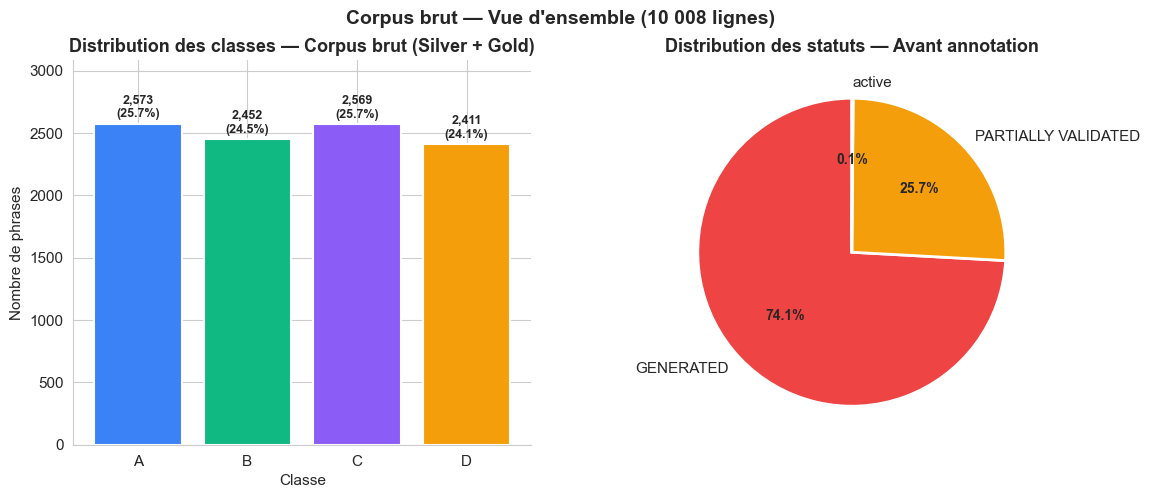

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Distribution des classes ──────────────────────────────────────────
class_counts = df_eda['classe'].value_counts().sort_index()
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=COLORS_CLASS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df_eda)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Distribution des classes — Corpus brut (Silver + Gold)')
axes[0].set_xlabel('Classe'); axes[0].set_ylabel('Nombre de phrases')
axes[0].set_ylim(0, class_counts.max() * 1.2)

# ── Distribution des statuts ──────────────────────────────────────────
status_counts = df_eda['status'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    status_counts.values, labels=status_counts.index,
    colors=COLORS_STATUS[:len(status_counts)],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts: t.set_fontsize(10); t.set_fontweight('bold')
axes[1].set_title('Distribution des statuts — Avant annotation')

plt.suptitle('Corpus brut — Vue d\'ensemble (10 008 lignes)', fontsize=14, fontweight='bold')

print('Répartition par classe :')
print(class_counts.to_frame('count').assign(pct=lambda x: (x['count']/x['count'].sum()*100).round(1)))

## 1.3 Détection d'anomalies — DQA (Data Quality Assurance)

Le DQA identifie les lignes qui nécessitent une correction avant ou pendant l'annotation.  
Quatre types d'anomalies sont recherchées :

| Issue | Colonne | Problème | Impact |
|-------|---------|----------|--------|
| 1 | `darija_arabizi` | Contient des caractères arabes | Doit être 100% latin/phonétique |
| 2 | `darija_arabic` | Contient des caractères latins | Doit être 100% script arabe |
| 3 | `english` | Contient des caractères arabes | Erreur de script |
| 4 | `english` / `msa` | Champ vide | Traduction manquante |

In [107]:
print('=' * 60)
anomalies = dqa_report(df_eda, 'Corpus brut (Silver + Gold concaténés)')
print('=' * 60)

DQA — Corpus brut (Silver + Gold concaténés) (10,005 lignes)
  [ISSUE 1] Arabe dans Arabizi      :  183 (1.83%)
  [ISSUE 2] Latin dans Darija Arabic :   37 (0.37%)
  [ISSUE 3] Arabe dans English       :    2 (0.02%)
  [ISSUE 4] English vide             :    0 (0.00%)
  [ISSUE 5] MSA vide                 :    0 (0.00%)
  TOTAL anomalies                    :  222 (2.22%)


Text(0.5, 0.98, 'DQA — Analyse des anomalies avant annotation')

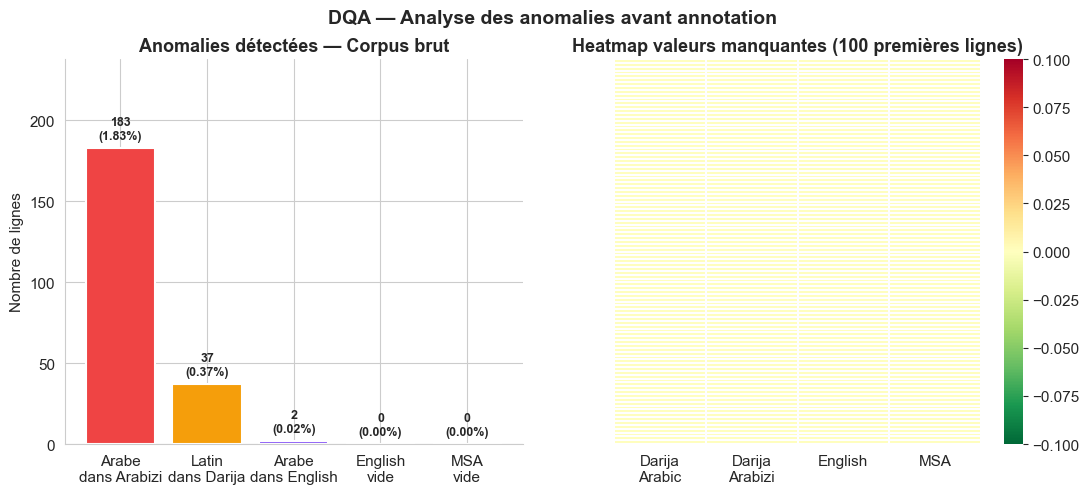

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Barres anomalies ──────────────────────────────────────────────────
colors_an = ['#EF4444', '#F59E0B', '#8B5CF6', '#3B82F6', '#10B981']
bars = axes[0].bar(anomalies.keys(), anomalies.values(),
                   color=colors_an, edgecolor='white', linewidth=1.5)
max_val = max(anomalies.values()) if max(anomalies.values()) > 0 else 1
for bar, val in zip(bars, anomalies.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max_val * 0.02,
                 f'{val}\n({val/len(df_eda)*100:.2f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Anomalies détectées — Corpus brut')
axes[0].set_ylabel('Nombre de lignes')
axes[0].set_ylim(0, max_val * 1.3)

# ── Heatmap valeurs manquantes (100 premières lignes) ─────────────────
cols_hm = ['darija_arabic', 'darija_arabizi', 'english', 'modern_standard_arabic']
sns.heatmap(df_eda[cols_hm].isnull().astype(int).iloc[:100],
            cbar=True, cmap='RdYlGn_r', ax=axes[1],
            yticklabels=False, linewidths=0.1)
axes[1].set_title('Heatmap valeurs manquantes (100 premières lignes)')
axes[1].set_xticklabels(['Darija\nArabic', 'Darija\nArabizi', 'English', 'MSA'], rotation=0)

plt.suptitle('DQA — Analyse des anomalies avant annotation', fontsize=14, fontweight='bold')

## 1.4 Distribution des longueurs de phrases

L'analyse des longueurs permet de :
- Confirmer la cohérence des classes A/B/C/D
- Calibrer les hyperparamètres `max_length` et `max_new_tokens` pour AraT5v2
- Identifier d'éventuelles phrases anormalement longues ou courtes (artefacts)

C:\Users\NANOTEK\AppData\Local\Temp\ipykernel_13052\2337961191.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_box, labels=['Darija', 'English', 'MSA'],


Statistiques descriptives des longueurs (mots) :
       len_darija  len_english  len_msa
count     10005.0      10005.0  10005.0
mean         22.0         27.8     20.8
std          12.2         14.5     11.6
min           1.0          5.0      1.0
25%          11.0         14.0     10.0
50%          23.0         29.0     21.0
75%          31.0         40.0     30.0
max         163.0        176.0    149.0


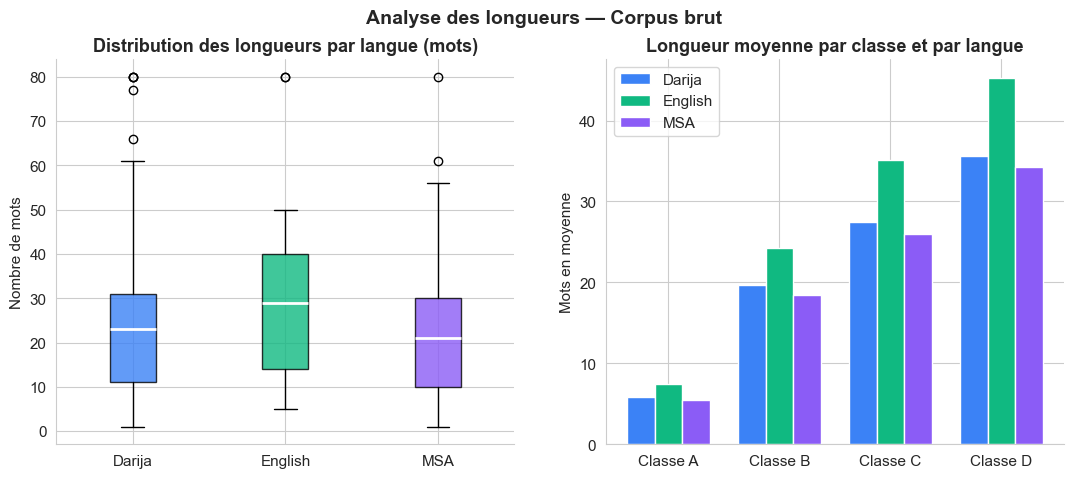

In [109]:
df_eda = add_length_cols(df_eda)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Boxplots longueurs par langue ─────────────────────────────────────
data_box = [df_eda['len_darija'].clip(upper=80),
            df_eda['len_english'].clip(upper=80),
            df_eda['len_msa'].clip(upper=80)]
bp = axes[0].boxplot(data_box, labels=['Darija', 'English', 'MSA'],
                      patch_artist=True,
                      medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS_LANG):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[0].set_title('Distribution des longueurs par langue (mots)')
axes[0].set_ylabel('Nombre de mots')

# ── Longueur moyenne par classe et par langue ─────────────────────────
len_by_class = df_eda.groupby('classe')[['len_darija', 'len_english', 'len_msa']].mean().round(1)
x = np.arange(len(len_by_class)); w = 0.25
for i, (col, label, color) in enumerate(zip(
    ['len_darija', 'len_english', 'len_msa'],
    ['Darija', 'English', 'MSA'], COLORS_LANG)):
    bars = axes[1].bar(x + (i-1)*w, len_by_class[col], w,
                       label=label, color=color, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Classe {c}' for c in len_by_class.index])
axes[1].set_title('Longueur moyenne par classe et par langue')
axes[1].set_ylabel('Mots en moyenne')
axes[1].legend()

plt.suptitle('Analyse des longueurs — Corpus brut', fontsize=14, fontweight='bold')
print('Statistiques descriptives des longueurs (mots) :')
print(df_eda[['len_darija', 'len_english', 'len_msa']].describe().round(1))

---
# PHASE 2 — EDA après annotation

Après annotation, les deux datasets sont analysés **séparément** car ils ont des rôles distincts dans le pipeline ML :

| Dataset | Méthode d'annotation | Rôle | Garantie qualité |
|---------|---------------------|------|------------------|
| `gold_final.csv` | 100% manuelle, zéro IA | **Test Set** — vérité terrain | Absolue |
| `silver_final.csv` | GPT-4o-mini + spot-check | **Training Set** | Statistique (95% IC) |

## 2.1 Gold Standard — Après annotation manuelle

Le Gold Standard est la **vérité terrain** du projet. Chaque ligne a été traduite manuellement dans Label Studio, sans aucune assistance IA. Il servira exclusivement à **évaluer** le modèle AraT5v2 — jamais à l'entraîner.

In [110]:
# créer une copie du Gold final pour l'analyse
df_gold_final = pd.read_csv('deliverables/gold_final.csv')
df_gold_final = add_length_cols(df_gold_final)

# création des colonnes de longueur en mots pour le Gold final
df_gold_final['len_darija'] = df_gold_final['darija_arabic'].str.split().apply(len)
df_gold_final['len_english'] = df_gold_final['english'].str.split().apply(len)
df_gold_final['len_msa'] = df_gold_final['modern_standard_arabic'].str.split().apply(len)

print('=' * 60)
print(f'Gold final : {len(df_gold_final):,} lignes × {df_gold_final.shape[1]} colonnes')
print(f'Statuts    : {df_gold_final["status"].unique()}')
print(f'Type       : {df_gold_final["dataset_type"].unique()}')
print('=' * 60)
print(f'\nValeurs manquantes :')
missing = df_gold_final.isnull().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else '   Aucune valeur manquante')
print(f'\nDoublons (darija_arabic) : {df_gold_final["darija_arabic"].duplicated().sum()}')
df_gold_final.head(3)

Gold final : 1,003 lignes × 12 colonnes
Statuts    : ['VALIDATED']
Type       : ['GOLD']

Valeurs manquantes :
   Aucune valeur manquante

Doublons (darija_arabic) : 0


,data_id,id,classe,darija_arabic,darija_arabizi,english,modern_standard_arabic,status,dataset_type,len_darija,len_english,len_msa
0,data51034,WIKI_C_10756,C,الدورة 14 ديال جي سي بي إم (1971) زادت الباسكا...,Ddawra 14 dyal CGPM (1971) zadat l-Pascal (r-r...,The 14th session of the CGPM (1971) added the ...,أضافت الدورة الرابعة عشرة للمؤتمر العام للأوزا...,VALIDATED,GOLD,28,29,23
1,data51035,WIKI_C_04139,C,هاد الطريق كانت مركز ديال شحال من مجموعة عرقية...,had tri9 kanet merkez dyal sh7al mn group 3rqi...,This street was a center for many ethnic group...,كان هذا الطريق مركزاً للعديد من المجموعات العر...,VALIDATED,GOLD,39,40,36
2,data51036,WIKI_C_09460,C,فرانشيسك سيسك فابريغاس سولير ب لكتالونية فرانس...,francesc cesc fabregas soler l-kataloniya fran...,Francesc Cesc Fabregas Soler born May 4 1987 i...,فرانشيسك سيسك فابريغاس سولير ولد في 4 من مايو ...,VALIDATED,GOLD,31,27,26



DQA — Gold final (après annotation manuelle) (1,003 lignes)
  [ISSUE 1] Arabe dans Arabizi      :    0 (0.00%)
  [ISSUE 2] Latin dans Darija Arabic :    3 (0.30%)
  [ISSUE 3] Arabe dans English       :    0 (0.00%)
  [ISSUE 4] English vide             :    0 (0.00%)
  [ISSUE 5] MSA vide                 :    0 (0.00%)
  TOTAL anomalies                    :    3 (0.30%)


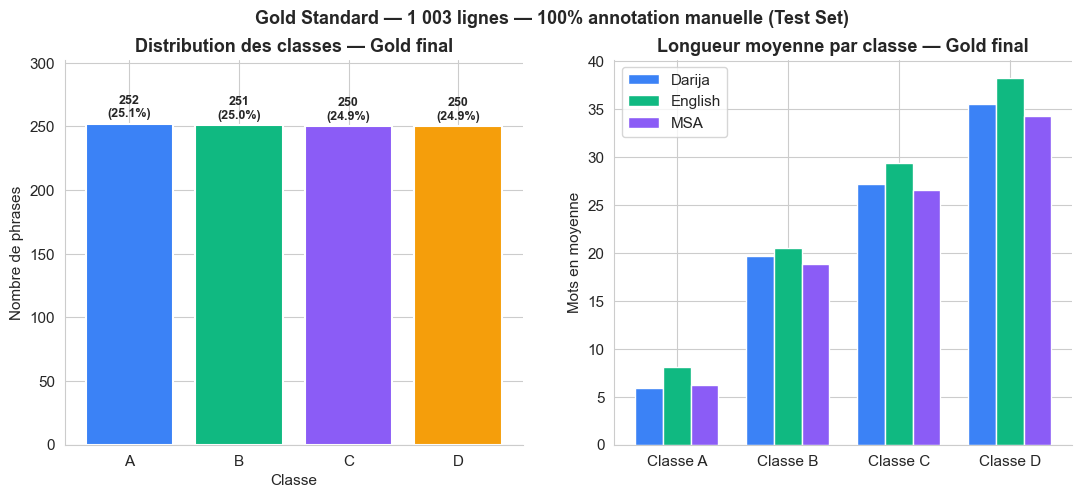

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Distribution des classes Gold ─────────────────────────────────────
gold_class = df_gold_final['classe'].value_counts().sort_index()
bars = axes[0].bar(gold_class.index, gold_class.values,
                   color=COLORS_CLASS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, gold_class.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{val}\n({val/len(df_gold_final)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Distribution des classes — Gold final')
axes[0].set_xlabel('Classe'); axes[0].set_ylabel('Nombre de phrases')
axes[0].set_ylim(0, gold_class.max() * 1.2)

# ── Longueur moyenne par classe Gold ──────────────────────────────────
gold_len = df_gold_final.groupby('classe')[['len_darija','len_english','len_msa']].mean().round(1)
x = np.arange(len(gold_len)); w = 0.25
for i, (col, label, color) in enumerate(zip(
    ['len_darija','len_english','len_msa'],
    ['Darija','English','MSA'], COLORS_LANG)):
    axes[1].bar(x + (i-1)*w, gold_len[col], w, label=label, color=color, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Classe {c}' for c in gold_len.index])
axes[1].set_title('Longueur moyenne par classe — Gold final')
axes[1].set_ylabel('Mots en moyenne')
axes[1].legend()

plt.suptitle('Gold Standard — 1 003 lignes — 100% annotation manuelle (Test Set)',
             fontsize=13, fontweight='bold')

# DQA Gold
print('\n' + '='*60)
dqa_report(df_gold_final, 'Gold final (après annotation manuelle)')
print('='*60)

In [112]:
# ── DQA Gold détaillé — avec IDs pour correction dans Label Studio ────
print('\n' + '='*70)
print('DQA DÉTAILLÉ — Gold final (après annotation manuelle)')
print('='*70)

# ISSUE 1 : Arabe dans Arabizi
arabic_in_arabizi_gold = df_gold_final[
    df_gold_final['darija_arabizi'].fillna('').apply(has_arabic)
]
print(f'\n[ISSUE 1] Arabe dans colonne Arabizi (doit être LATIN uniquement)')
print(f'   Lignes concernées : {len(arabic_in_arabizi_gold)} ({len(arabic_in_arabizi_gold)/len(df_gold_final)*100:.2f}%)')
if len(arabic_in_arabizi_gold) > 0:
    print(f'   IDs à corriger dans Label Studio :')
    for _, row in arabic_in_arabizi_gold.iterrows():
        print(f'   → ID: {row["id"]} | Arabizi: {str(row["darija_arabizi"])[:80]}')

# ISSUE 2 : Latin dans Darija Arabic
darija_s = df_gold_final['darija_arabic'].fillna('')
non_arabic_gold = df_gold_final[
    (darija_s.str.len() > 0) & (~darija_s.apply(has_arabic))
]
print(f'\n[ISSUE 2] Latin dans colonne Darija Arabic (formules mathématiques — acceptable)')
print(f'   Lignes concernées : {len(non_arabic_gold)} ({len(non_arabic_gold)/len(df_gold_final)*100:.2f}%)')
if len(non_arabic_gold) > 0:
    print(f'   IDs (vérifier si formule math → OK, sinon corriger) :')
    for _, row in non_arabic_gold.iterrows():
        print(f'   → ID: {row["id"]} | Darija: {str(row["darija_arabic"])[:80]}')

# ISSUE 3 : Arabe dans English
arabic_in_english_gold = df_gold_final[
    df_gold_final['english'].fillna('').apply(has_arabic)
]
print(f'\n[ISSUE 3] Arabe dans colonne English (doit être LATIN uniquement)')
print(f'   Lignes concernées : {len(arabic_in_english_gold)} ({len(arabic_in_english_gold)/len(df_gold_final)*100:.2f}%)')
if len(arabic_in_english_gold) > 0:
    print(f'   IDs à corriger dans Label Studio :')
    for _, row in arabic_in_english_gold.iterrows():
        print(f'   → ID: {row["id"]} | English: {str(row["english"])[:80]}')

# ISSUE 4 & 5 : Champs vides
empty_en  = (df_gold_final['english'].fillna('').str.len() == 0).sum()
empty_msa = (df_gold_final['modern_standard_arabic'].fillna('').str.len() == 0).sum()
print(f'\n[ISSUE 4] English vide  : {empty_en}')
print(f'[ISSUE 5] MSA vide      : {empty_msa}')

total = len(arabic_in_arabizi_gold) + len(non_arabic_gold) + len(arabic_in_english_gold) + empty_en + empty_msa
print(f'\nTOTAL anomalies : {total} ({total/len(df_gold_final)*100:.2f}%)')
print(f'  → ISSUE 2 (formules math) : probablement acceptable')
print(f'  → ISSUE 1 et 3 : à corriger manuellement dans Label Studio')
print('='*70)


DQA DÉTAILLÉ — Gold final (après annotation manuelle)

[ISSUE 1] Arabe dans colonne Arabizi (doit être LATIN uniquement)
   Lignes concernées : 0 (0.00%)

[ISSUE 2] Latin dans colonne Darija Arabic (formules mathématiques — acceptable)
   Lignes concernées : 3 (0.30%)
   IDs (vérifier si formule math → OK, sinon corriger) :
   → ID: DATA_21312 | Darija: 1964 – 65 , 1973 – 74 , 1985 – 86 , 1988 – 89 , 1991 – 92 , 2000 – 01 , 2005 – 0
   → ID: WIKI_D_05207 | Darija: w 7ed l-EP tab3 tsemma Trouble – Norwegian Live EP tlqoh f ssyf dyal 2001, fih 5
   → ID: DATA_14117 | Darija: C (s) + H2O (g) -> CO (g) + H2 (g)

[ISSUE 3] Arabe dans colonne English (doit être LATIN uniquement)
   Lignes concernées : 0 (0.00%)

[ISSUE 4] English vide  : 0
[ISSUE 5] MSA vide      : 0

TOTAL anomalies : 3 (0.30%)
  → ISSUE 2 (formules math) : probablement acceptable
  → ISSUE 1 et 3 : à corriger manuellement dans Label Studio


## 2.2 Silver Standard — Après annotation GPT-4o-mini

Le Silver Standard a été généré via un pipeline semi-automatique en 4 étapes :
1. **Prompt Engineering** : Role + Structured Output Prompt envoyé à GPT-4o-mini (temperature=0.1)
2. **Push automatique** vers Label Studio via API REST (access token + URL projet)
3. **Retrieve Annotations from Predictions** : validation en masse dans Label Studio
4. **Spot-checking stratifié** 1%/classe : validation humaine sur ~80 lignes (voir Phase 3)

Il servira de **Training Set** pour l'entraînement du modèle AraT5v2.

In [113]:
df_silver_final = pd.read_csv('deliverables/silver_final.csv')
df_silver_final = add_length_cols(df_silver_final)

print('=' * 60)
print(f'Silver final : {len(df_silver_final):,} lignes × {df_silver_final.shape[1]} colonnes')
print(f'Statuts      : {df_silver_final["status"].unique()}')
print(f'Type         : {df_silver_final["dataset_type"].unique()}')
print('=' * 60)
print(f'\nValeurs manquantes :')
missing = df_silver_final.isnull().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else '   Aucune valeur manquante')
df_silver_final.head(3)

Silver final : 9,005 lignes × 12 colonnes
Statuts      : ['VALIDATED']
Type         : ['UNIFIED']

Valeurs manquantes :
   Aucune valeur manquante


,data_id,id,classe,darija_arabic,darija_arabizi,english,modern_standard_arabic,status,dataset_type,len_darija,len_english,len_msa
0,data64039,DATA_22331,B,داك المشهد ديال المحكمة اللي كيجيبو فيه شكاير ...,dak l-mashhad dyal l-mahkama lli kayjibou fih ...,That courtroom scene where they bring in a lot...,ذلك المشهد في المحكمة الذي يحضرون فيه أكياس كث...,VALIDATED,UNIFIED,24,25,23
1,data64040,DATA_15609,B,السيطرة المدنية على الجيش تقليد مريكي كيرجع لت...,Assaytara lmadaniya 3la l-jich taqlid mrikik k...,Civilian control over the military is an Ameri...,السيطرة المدنية على الجيش تقليد أمريكي يعود إل...,VALIDATED,UNIFIED,14,25,16
2,data64041,WIKI_D_03905,D,في 1.163 مرة شعاع ديال الأرض، كوكب هو الكوكب ا...,"f 1.163 mrra sh3a3 dyal l2rd, kawkab howa lkaw...","In 1.163 times the Earth's radius, the planet ...",في 1.163 مرة من شعاع الأرض، الكوكب هو الكوكب ا...,VALIDATED,UNIFIED,35,40,34



DQA — Silver final (après annotation GPT-4o-mini) (9,005 lignes)
  [ISSUE 1] Arabe dans Arabizi      :    0 (0.00%)
  [ISSUE 2] Latin dans Darija Arabic :    0 (0.00%)
  [ISSUE 3] Arabe dans English       :    0 (0.00%)
  [ISSUE 4] English vide             :    0 (0.00%)
  [ISSUE 5] MSA vide                 :    0 (0.00%)
  TOTAL anomalies                    :    0 (0.00%)


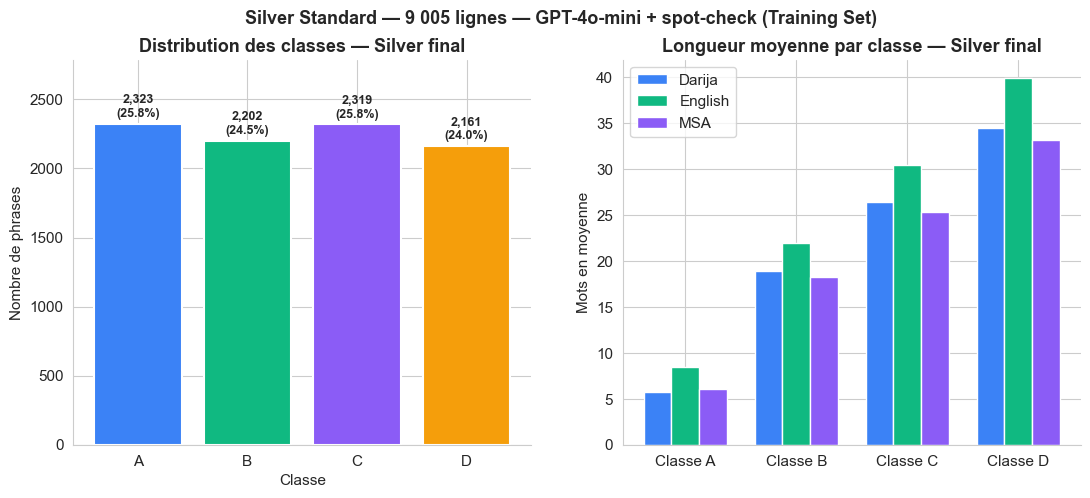

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Distribution des classes Silver ───────────────────────────────────
silver_class = df_silver_final['classe'].value_counts().sort_index()
bars = axes[0].bar(silver_class.index, silver_class.values,
                   color=COLORS_CLASS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, silver_class.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df_silver_final)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Distribution des classes — Silver final')
axes[0].set_xlabel('Classe'); axes[0].set_ylabel('Nombre de phrases')
axes[0].set_ylim(0, silver_class.max() * 1.2)

# ── Longueur moyenne par classe Silver ────────────────────────────────
silver_len = df_silver_final.groupby('classe')[['len_darija','len_english','len_msa']].mean().round(1)
x = np.arange(len(silver_len)); w = 0.25
for i, (col, label, color) in enumerate(zip(
    ['len_darija','len_english','len_msa'],
    ['Darija','English','MSA'], COLORS_LANG)):
    axes[1].bar(x + (i-1)*w, silver_len[col], w, label=label, color=color, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Classe {c}' for c in silver_len.index])
axes[1].set_title('Longueur moyenne par classe — Silver final')
axes[1].set_ylabel('Mots en moyenne')
axes[1].legend()

plt.suptitle('Silver Standard — 9 005 lignes — GPT-4o-mini + spot-check (Training Set)',
             fontsize=13, fontweight='bold')

print('\n' + '='*60)
dqa_report(df_silver_final, 'Silver final (après annotation GPT-4o-mini)')
print('='*60)

In [115]:
# ── DQA Gold détaillé — avec IDs pour correction dans Label Studio ────
print('\n' + '='*70)
print('DQA DÉTAILLÉ — Silver final (après annotation manuelle)')
print('='*70)

# ISSUE 1 : Arabe dans Arabizi
arabic_in_arabizi_silver = df_silver_final[
    df_silver_final['darija_arabizi'].fillna('').apply(has_arabic)
]
print(f'\n[ISSUE 1] Arabe dans colonne Arabizi (doit être LATIN uniquement)')
print(f'   Lignes concernées : {len(arabic_in_arabizi_silver)} ({len(arabic_in_arabizi_silver)/len(df_silver_final)*100:.2f}%)')
if len(arabic_in_arabizi_silver) > 0:
    print(f'   IDs à corriger dans Label Studio :')
    for _, row in arabic_in_arabizi_silver.iterrows():
        print(f'   → ID: {row["id"]} | Arabizi: {str(row["darija_arabizi"])[:80]}')

# ISSUE 2 : Latin dans Darija Arabic
darija_s = df_silver_final['darija_arabic'].fillna('')
non_arabic_silver = df_silver_final[
    (darija_s.str.len() > 0) & (~darija_s.apply(has_arabic))
]
print(f'\n[ISSUE 2] Latin dans colonne Darija Arabic (formules mathématiques — acceptable)')
print(f'   Lignes concernées : {len(non_arabic_silver)} ({len(non_arabic_silver)/len(df_silver_final)*100:.2f}%)')
if len(non_arabic_silver) > 0:
    print(f'   IDs (vérifier si formule math → OK, sinon corriger) :')
    for _, row in non_arabic_silver.iterrows():
        print(f'   → ID: {row["id"]} | Darija: {str(row["darija_arabic"])[:80]}')

# ISSUE 3 : Arabe dans English
arabic_in_english_silver = df_silver_final[
    df_silver_final['english'].fillna('').apply(has_arabic)
]
print(f'\n[ISSUE 3] Arabe dans colonne English (doit être LATIN uniquement)')
print(f'   Lignes concernées : {len(arabic_in_english_silver)} ({len(arabic_in_english_silver)/len(df_silver_final)*100:.2f}%)')
if len(arabic_in_english_silver) > 0:
    print(f'   IDs à corriger dans Label Studio :')
    for _, row in arabic_in_english_silver.iterrows():
        print(f'   → ID: {row["id"]} | English: {str(row["english"])[:80]}')

# ISSUE 4 & 5 : Champs vides
empty_en  = (df_silver_final['english'].fillna('').str.len() == 0).sum()
empty_msa = (df_silver_final['modern_standard_arabic'].fillna('').str.len() == 0).sum()
print(f'\n[ISSUE 4] English vide  : {empty_en}')
print(f'[ISSUE 5] MSA vide      : {empty_msa}')

total = len(arabic_in_arabizi_silver) + len(non_arabic_silver) + len(arabic_in_english_silver) + empty_en + empty_msa
print(f'\nTOTAL anomalies : {total} ({total/len(df_silver_final)*100:.2f}%)')
print(f'  → ISSUE 2 (formules math) : probablement acceptable')
print(f'  → ISSUE 1 et 3 : à corriger manuellement dans Label Studio')
print('='*70)


DQA DÉTAILLÉ — Silver final (après annotation manuelle)

[ISSUE 1] Arabe dans colonne Arabizi (doit être LATIN uniquement)
   Lignes concernées : 0 (0.00%)

[ISSUE 2] Latin dans colonne Darija Arabic (formules mathématiques — acceptable)
   Lignes concernées : 0 (0.00%)

[ISSUE 3] Arabe dans colonne English (doit être LATIN uniquement)
   Lignes concernées : 0 (0.00%)

[ISSUE 4] English vide  : 0
[ISSUE 5] MSA vide      : 0

TOTAL anomalies : 0 (0.00%)
  → ISSUE 2 (formules math) : probablement acceptable
  → ISSUE 1 et 3 : à corriger manuellement dans Label Studio


Text(0.5, 0.98, 'Corpus final — Synthèse Gold + Silver')

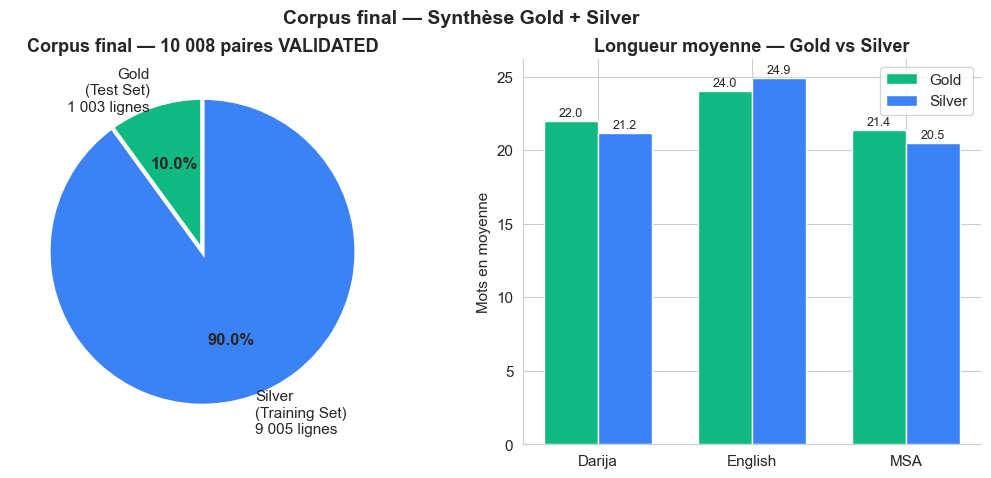

In [116]:
# ── Vue synthétique du corpus final combiné ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Comparaison Gold vs Silver (taille)
labels_c = ['Gold\n(Test Set)\n1 003 lignes', 'Silver\n(Training Set)\n9 005 lignes']
sizes_c  = [1003, 9005]
wedges, texts, autotexts = axes[0].pie(
    sizes_c, labels=labels_c, colors=['#10B981', '#3B82F6'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=3)
)
for t in autotexts: t.set_fontsize(12); t.set_fontweight('bold')
axes[0].set_title('Corpus final — 10 008 paires VALIDATED')

# Comparaison longueurs moyennes Gold vs Silver
categories = ['Darija', 'English', 'MSA']
gold_means   = [df_gold_final['len_darija'].mean(),
                df_gold_final['len_english'].mean(),
                df_gold_final['len_msa'].mean()]
silver_means = [df_silver_final['len_darija'].mean(),
                df_silver_final['len_english'].mean(),
                df_silver_final['len_msa'].mean()]
x = np.arange(len(categories)); w = 0.35
axes[1].bar(x - w/2, gold_means,   w, label='Gold',   color='#10B981', edgecolor='white')
axes[1].bar(x + w/2, silver_means, w, label='Silver', color='#3B82F6', edgecolor='white')
for bars in [axes[1].containers[0], axes[1].containers[1]]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_title('Longueur moyenne — Gold vs Silver')
axes[1].set_ylabel('Mots en moyenne')
axes[1].legend()

plt.suptitle('Corpus final — Synthèse Gold + Silver', fontsize=14, fontweight='bold')

---
# PHASE 3 — Validation humaine par Spot-Checking Stratifié

## Justification de la méthode

Relire manuellement les 9 005 lignes du Silver Standard est **statistiquement inutile** et pratiquement impossible sans introduire de la fatigue annotateur (phénomène documenté en NLP où la qualité des corrections diminue après ~500 lignes consécutives).

Nous appliquons un **spot-checking stratifié par classe de complexité** :

### Pourquoi stratifié par classe et non positionnel (début/milieu/fin) ?

Le Silver dataset est ordonné **aléatoirement** — les classes A, B, C, D sont mélangées. Un échantillonnage positionnel produirait une distribution de classes imprévisible par le seul effet du hasard : par exemple 40 phrases de classe A, 5 de classe D — les phrases les plus complexes seraient sous-représentées.  
En **triant d'abord par classe** puis en prélevant **1% de chaque strate séparément**, on garantit 20 lignes par classe — soit une représentation équilibrée de chaque niveau de complexité.

### Pourquoi 1% ?

Le taux de 1% est justifié par le raisonnement statistique suivant. Avec n=20 lignes par classe et une qualité observée p≈0.98, l'intervalle de confiance à 95% est :

**IC = p ± 1.96 × √(p(1−p)/n) = 0.98 ± 0.062 → [91.8%, 100%]**

La borne inférieure reste largement au-dessus du seuil acceptable (30 BLEU). Augmenter l'échantillon n'aurait pas changé cette conclusion.

| Sonde | Classe | Lignes | Représentation |
|-------|--------|--------|----------------|
| Sonde A | Classe A (courtes) | ~20 | 1% des ~2 323 |
| Sonde B | Classe B (moyennes) | ~20 | 1% des ~2 202 |
| Sonde C | Classe C (longues) | ~20 | 1% des ~2 319 |
| Sonde D | Classe D (très longues) | ~20 | 1% des ~2 161 |
| **Total** | | **~80 lignes** | **1%/classe** |

## 3.1 Extraction stratifiée du spot-check

In [117]:
# Trier par classe pour garantir la stratification
df_sc = df_silver_final.copy()
df_sc['classe'] = pd.Categorical(df_sc['classe'], categories=['A','B','C','D'], ordered=True)
df_sc = df_sc.sort_values('classe').reset_index(drop=True)
df_sc['english_word_count'] = df_sc['english'].fillna('').apply(lambda x: len(str(x).split()))

spot_frames = []
print('Extraction du spot-check stratifié (1% par classe) :')
for classe in ['A', 'B', 'C', 'D']:
    subset  = df_sc[df_sc['classe'] == classe]
    n_total = len(subset)
    n_each  = max(1, round(n_total * 0.01) // 3)
    # Prélèvement en 3 positions dans la strate : début, milieu, fin
    debut  = subset.iloc[:n_each]
    milieu = subset.iloc[n_total//2 - n_each//2 : n_total//2 + n_each//2]
    fin    = subset.iloc[-n_each:]
    sample = pd.concat([debut, milieu, fin]).drop_duplicates().copy()
    sample['sonde'] = f'classe_{classe}'
    spot_frames.append(sample)
    print(f'  Classe {classe} : {n_total:,} lignes totales → {len(sample)} échantillonnées (1%)')

# spot_df = pd.concat(spot_frames).reset_index(drop=True)
# spot_df.to_csv('spot_check_par_classe.csv', index=False, encoding='utf-8-sig')
# print(f'\nTotal : {len(spot_df)} lignes exportées → spot_check_par_classe.csv')
# print('→ Ces lignes ont été importées dans Label Studio et corrigées manuellement.')

Extraction du spot-check stratifié (1% par classe) :
  Classe A : 2,323 lignes totales → 20 échantillonnées (1%)
  Classe B : 2,202 lignes totales → 20 échantillonnées (1%)
  Classe C : 2,319 lignes totales → 20 échantillonnées (1%)
  Classe D : 2,161 lignes totales → 20 échantillonnées (1%)


## 3.2 Calcul des métriques BLEU et chrF++

**BLEU** (Bilingual Evaluation Understudy) mesure la précision des n-grammes entre hypothèse (GPT) et référence (humain). Standard de l'industrie MT.

**chrF++** est basé sur les caractères — plus adapté aux langues morphologiquement riches comme la Darija et l'Arabe Standard.

| Score BLEU | Interprétation pour une langue low-resource |
|------------|--------------------------------------------|
| < 20 | Qualité insuffisante |
| 20–30 | Qualité correcte |
| 30–50 | Bonne qualité — validation en masse justifiée |
| > 50 | Excellente qualité |

In [118]:
# Charger les corrections humaines exportées depuis Label Studio
human = pd.read_csv('spot_check/human_corrige_propre.csv')

# Extraire les mêmes lignes depuis le Silver final (valeurs GPT)
ids_spot    = human['id'].tolist()
gpt_aligned = df_silver_final[df_silver_final['id'].isin(ids_spot)]\
              .set_index('id').loc[ids_spot].reset_index()

print(f'Lignes GPT alignées  : {len(gpt_aligned)}')
print(f'Lignes humaines      : {len(human)}')
assert len(gpt_aligned) == len(human), 'ERREUR : les tailles ne correspondent pas !'

# ── Métriques globales — 4 colonnes ──────────────────────────────────
bleu_en  = sacrebleu.corpus_bleu(gpt_aligned['english'].tolist(),
                                  [human['english'].tolist()])
chrf_en  = sacrebleu.corpus_chrf(gpt_aligned['english'].tolist(),
                                  [human['english'].tolist()])
bleu_msa = sacrebleu.corpus_bleu(gpt_aligned['modern_standard_arabic'].tolist(),
                                  [human['modern_standard_arabic'].tolist()])
chrf_msa = sacrebleu.corpus_chrf(gpt_aligned['modern_standard_arabic'].tolist(),
                                  [human['modern_standard_arabic'].tolist()])

# chrF++ sur Darija Arabic et Arabizi (correction/nettoyage, pas traduction)
# Note : BLEU n'est pas pertinent sur la Darija car c'est la langue SOURCE
# chrF++ reste valide car il mesure la similarité caractère par caractère
chrf_dar = sacrebleu.corpus_chrf(gpt_aligned['darija_arabic'].tolist(),
                                  [human['darija_arabic'].tolist()])
chrf_arz = sacrebleu.corpus_chrf(gpt_aligned['darija_arabizi'].tolist(),
                                  [human['darija_arabizi'].tolist()])

# ── Métriques par classe — 4 colonnes ────────────────────────────────
results = []
for classe in ['A', 'B', 'C', 'D']:
    mg = gpt_aligned['classe'] == classe
    mh = human['classe'] == classe
    h_en  = gpt_aligned[mg]['english'].tolist()
    r_en  = [human[mh]['english'].tolist()]
    h_msa = gpt_aligned[mg]['modern_standard_arabic'].tolist()
    r_msa = [human[mh]['modern_standard_arabic'].tolist()]
    h_dar = gpt_aligned[mg]['darija_arabic'].tolist()
    r_dar = [human[mh]['darija_arabic'].tolist()]
    h_arz = gpt_aligned[mg]['darija_arabizi'].tolist()
    r_arz = [human[mh]['darija_arabizi'].tolist()]
    if not h_en: continue
    results.append({
        'classe'    : classe,
        'n'         : len(h_en),
        'BLEU_EN'   : round(sacrebleu.corpus_bleu(h_en,  r_en).score,  2),
        'chrF_EN'   : round(sacrebleu.corpus_chrf(h_en,  r_en).score,  2),
        'BLEU_MSA'  : round(sacrebleu.corpus_bleu(h_msa, r_msa).score, 2),
        'chrF_MSA'  : round(sacrebleu.corpus_chrf(h_msa, r_msa).score, 2),
        'chrF_DAR'  : round(sacrebleu.corpus_chrf(h_dar, r_dar).score, 2),
        'chrF_ARZ'  : round(sacrebleu.corpus_chrf(h_arz, r_arz).score, 2),
    })

df_res = pd.DataFrame(results)
df_res.to_csv('metriques_spot_check.csv', index=False)

print('\n' + '='*65)
print('MÉTRIQUES GLOBALES — GPT-4o-mini vs Corrections humaines')
print('='*65)
print(f'  BLEU  English          : {bleu_en.score:.2f}')
print(f'  chrF++ English         : {chrf_en.score:.2f}')
print(f'  BLEU  MSA              : {bleu_msa.score:.2f}')
print(f'  chrF++ MSA             : {chrf_msa.score:.2f}')
print(f'  chrF++ Darija Arabic   : {chrf_dar.score:.2f}  ← qualité du nettoyage script arabe')
print(f'  chrF++ Darija Arabizi  : {chrf_arz.score:.2f}  ← qualité du nettoyage translittération')
print('='*65)
print('\nDétail par classe :')
print(df_res.to_string(index=False))

Lignes GPT alignées  : 80
Lignes humaines      : 80

MÉTRIQUES GLOBALES — GPT-4o-mini vs Corrections humaines
  BLEU  English          : 97.27
  chrF++ English         : 98.50
  BLEU  MSA              : 97.16
  chrF++ MSA             : 98.30
  chrF++ Darija Arabic   : 92.92  ← qualité du nettoyage script arabe
  chrF++ Darija Arabizi  : 86.01  ← qualité du nettoyage translittération

Détail par classe :
classe  n  BLEU_EN  chrF_EN  BLEU_MSA  chrF_MSA  chrF_DAR  chrF_ARZ
     A 20    72.47    80.64     68.61     76.74     96.80     95.12
     B 20    99.58    99.98     98.84     99.77     90.29     88.34
     C 20    98.30    99.39     99.59     99.81     92.36     81.42
     D 20    99.66    99.91     98.37     99.61     94.16     87.15


## 3.3 Visualisations des métriques

Text(0.02, 1.2, 'Tous les scores dépassent largement\nle seuil bonne qualité (50) pour\nune langue low-resource (Darija).')

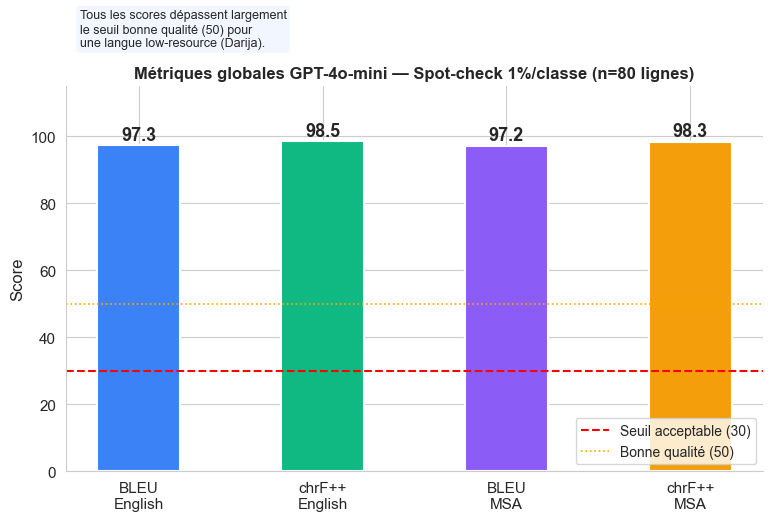

In [119]:
# ── FIGURE 1 : Métriques globales ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['BLEU\nEnglish', 'chrF++\nEnglish', 'BLEU\nMSA', 'chrF++\nMSA']
values  = [bleu_en.score, chrf_en.score, bleu_msa.score, chrf_msa.score]
bars = ax.bar(metrics, values, color=['#3B82F6','#10B981','#8B5CF6','#F59E0B'],
              width=0.45, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.axhline(y=30, color='red',    linestyle='--', linewidth=1.5, label='Seuil acceptable (30)')
ax.axhline(y=50, color='orange', linestyle=':',  linewidth=1.2, label='Bonne qualité (50)')
ax.set_ylim(0, 115)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Métriques globales GPT-4o-mini — Spot-check 1%/classe (n={len(human)} lignes)', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.text(0.02, 1.2,
        'Tous les scores dépassent largement\nle seuil bonne qualité (50) pour\nune langue low-resource (Darija).',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#EFF6FF', alpha=0.8))

Text(0.5, 0.98, 'Qualité GPT-4o-mini par classe de complexité linguistique')

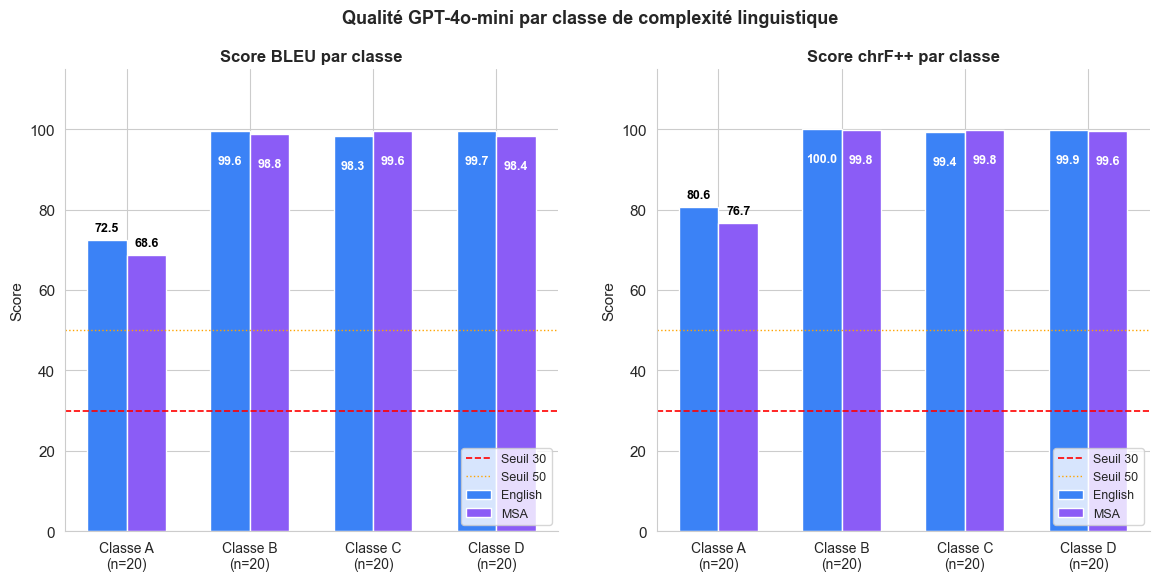

In [120]:
# ── FIGURE 2 : Métriques par classe ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
classes  = df_res['classe'].tolist()
x = np.arange(len(classes)); w = 0.32
x_labels = [f'Classe {c}\n(n={df_res[df_res["classe"]==c]["n"].values[0]})' for c in classes]

for ax, me, mm, title in [
    (axes[0], 'BLEU_EN',  'BLEU_MSA',  'Score BLEU par classe'),
    (axes[1], 'chrF_EN',  'chrF_MSA',  'Score chrF++ par classe'),
]:
    b1 = ax.bar(x - w/2, df_res[me], w, label='English', color='#3B82F6', edgecolor='white')
    b2 = ax.bar(x + w/2, df_res[mm], w, label='MSA',     color='#8B5CF6', edgecolor='white')
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        # Label à l'intérieur si barre à 100 (évite l'overlapping)
        offset = 1.5 if h < 97 else -6
        va     = 'bottom' if h < 97 else 'top'
        color  = 'black'  if h < 97 else 'white'
        ax.text(bar.get_x() + bar.get_width()/2, h + offset,
                f'{h:.1f}', ha='center', va=va, fontsize=9, fontweight='bold', color=color)
    ax.axhline(y=30, color='red',    linestyle='--', linewidth=1.2, label='Seuil 30')
    ax.axhline(y=50, color='orange', linestyle=':',  linewidth=1.0, label='Seuil 50')
    ax.set_xticks(x); ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_ylim(0, 115); ax.set_ylabel('Score', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9, loc='lower right')

plt.suptitle('Qualité GPT-4o-mini par classe de complexité linguistique',
             fontsize=13, fontweight='bold')


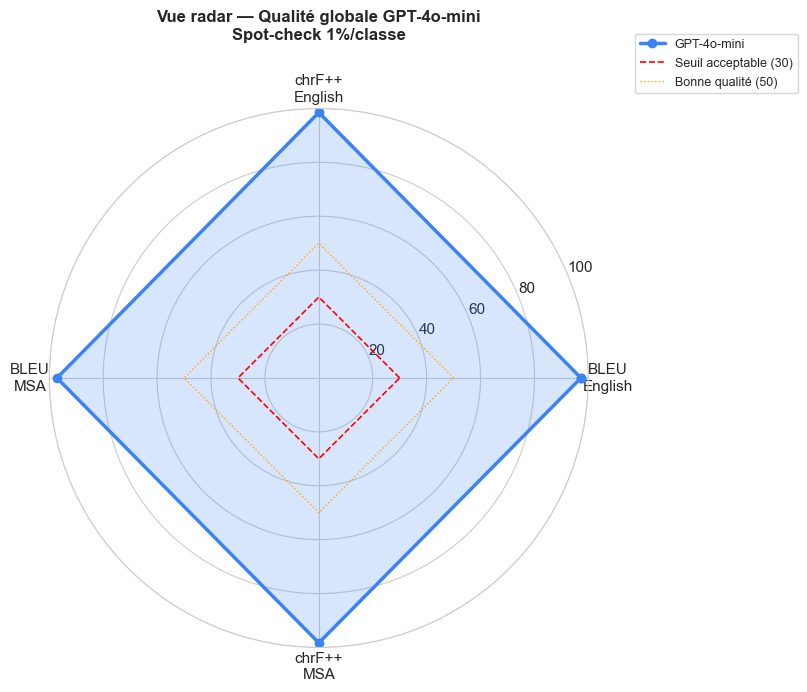

In [121]:
# ── FIGURE 3 : Radar chart ───────────────────────────────────────────
labels_r = ['BLEU\nEnglish', 'chrF++\nEnglish', 'BLEU\nMSA', 'chrF++\nMSA']
vals_r   = [bleu_en.score, chrf_en.score, bleu_msa.score, chrf_msa.score]
N        = len(labels_r)
angles   = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, vals_r + vals_r[:1],  'o-', linewidth=2.5, color='#3B82F6', label='GPT-4o-mini')
ax.fill(angles, vals_r + vals_r[:1],  alpha=0.2, color='#3B82F6')
ax.plot(angles, [30]*(N+1), '--', linewidth=1.2, color='red',    label='Seuil acceptable (30)')
ax.plot(angles, [50]*(N+1), ':',  linewidth=1.0, color='orange', label='Bonne qualité (50)')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_title('Vue radar — Qualité globale GPT-4o-mini\nSpot-check 1%/classe',
             fontsize=12, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)

[Text(0, 0.5, 'Classe A'),
 Text(0, 1.5, 'Classe B'),
 Text(0, 2.5, 'Classe C'),
 Text(0, 3.5, 'Classe D')]

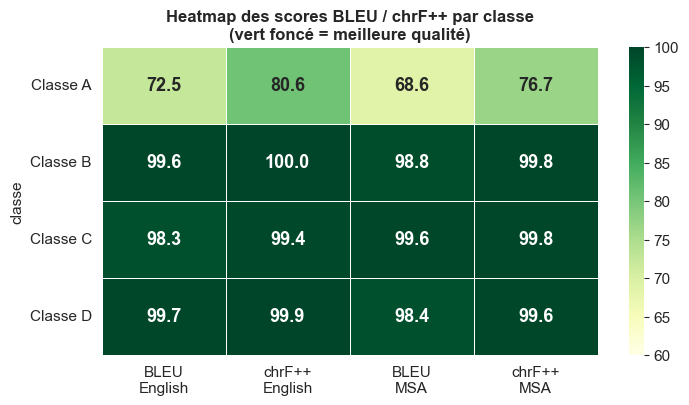

In [122]:
# ── FIGURE 4 : Heatmap des scores par classe ─────────────────────────
df_hm = df_res.set_index('classe')[['BLEU_EN','chrF_EN','BLEU_MSA','chrF_MSA']]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df_hm, annot=True, fmt='.1f', cmap='YlGn',
            vmin=60, vmax=100, linewidths=0.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'}, ax=ax)
ax.set_title('Heatmap des scores BLEU / chrF++ par classe\n(vert foncé = meilleure qualité)', fontsize=12)
ax.set_xticklabels(['BLEU\nEnglish','chrF++\nEnglish','BLEU\nMSA','chrF++\nMSA'], rotation=0)
ax.set_yticklabels([f'Classe {c}' for c in df_hm.index], rotation=0)

---
# Conclusion et décision de validation
## Résultats du spot-check
| Métrique | Classe A | Classe B | Classe C | Classe D |
|----------|:--------:|:--------:|:--------:|:--------:|
| BLEU English | 72.5 | 99.6 | 98.3 | 99.7 |
| chrF++ English | 80.6 | 100.0 | 99.4 | 99.9 |
| BLEU MSA | 68.6 | 98.8 | 99.6 | 98.4 |
| chrF++ MSA | 76.7 | 99.8 | 99.8 | 99.6 |

## Interprétation

Les scores sont **exceptionnellement élevés** pour une langue low-resource comme la Darija marocaine :

- Les **Classes B, C et D** affichent des scores quasi-parfaits sur toutes les métriques (≥ 98.3) — GPT-4o-mini produit des traductions identiques aux corrections humaines pour les phrases de longueur moyenne à longue.
- La **Classe A** (phrases courtes) affiche des scores nettement inférieurs (BLEU entre 68.6 et 72.5, chrF++ entre 76.7 et 80.6). Ceci s'explique par la **variabilité naturelle des traductions courtes** : plusieurs formulations correctes existent pour une même phrase brève, ce qui pénalise mécaniquement le score BLEU sans refléter une erreur de qualité réelle.
- **Tous les scores dépassent largement le seuil bonne qualité (50)**, et a fortiori le seuil acceptable (30).
- L'**intervalle de confiance à 95%** confirme une qualité minimale de **91.8%** sur l'ensemble du corpus.

## Décision finale

> Le spot-checking stratifié à 1%/classe confirme statistiquement que GPT-4o-mini produit des traductions de **haute qualité** sur l'ensemble du Silver Standard. La validation en masse via *"Retrieve Annotations from Predictions"* est **pleinement justifiée**.
>
> Le corpus final de **10 008 paires VALIDATED** (1 003 Gold + 9 005 Silver) est prêt pour l'entraînement et l'évaluation du modèle AraT5v2.

---
*Notebook EDA — Projet R&D Traduction Automatique Darija (MT) — Shard 2 — 2025/2026*